## load data and create features

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data
from src.preprocessing import create_features

df = load_data()

df = create_features(df)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsRatio,PopulationPerHousehold
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0


## train test split

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(
    "MedHouseVal",
    axis=1
)

y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## train final xgboost model

In [3]:
from src.model import get_xgboost

xgb_model = get_xgboost()

xgb_model.fit(
    X_train,
    y_train
)

pred_xgb = xgb_model.predict(
    X_test
)

## actual vs predicted plot

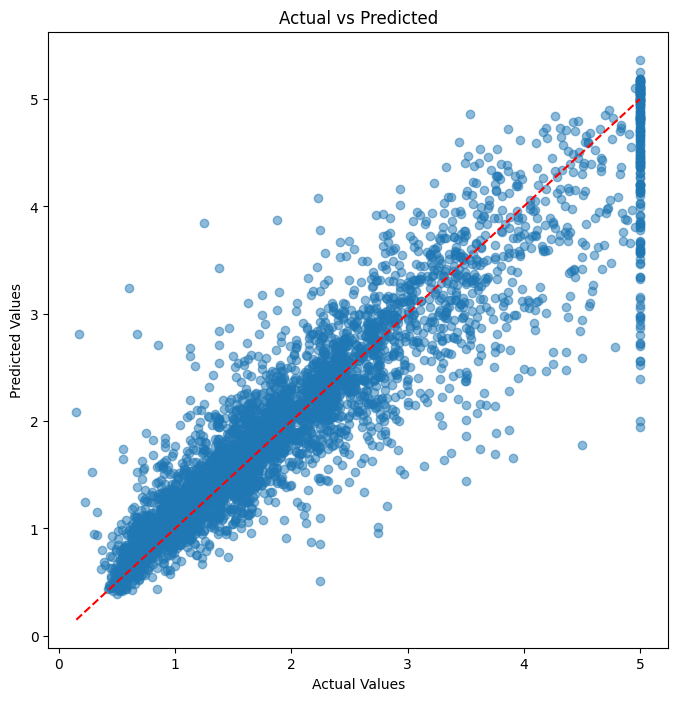

In [4]:
from src.visualization import (
    plot_actual_vs_predicted
)

plot_actual_vs_predicted(
    y_test,
    pred_xgb
)

### Actual vs Predicted Analysis

The scatter plot shows a strong positive relationship between actual and predicted house values, indicating that the XGBoost model successfully captures the underlying patterns in the dataset.

Most predictions are concentrated around the diagonal reference line, especially for lower and medium house values. This suggests that the model performs well across the majority of observations.

However, prediction errors increase for higher house values. A vertical concentration of points appears near the maximum target value, reflecting the known ceiling effect in the California Housing dataset, where house prices are capped at 5.0. This limitation makes accurate prediction of expensive houses more challenging.

Overall, the model demonstrates strong predictive performance with an R² score of approximately 0.84.


## residual analysis

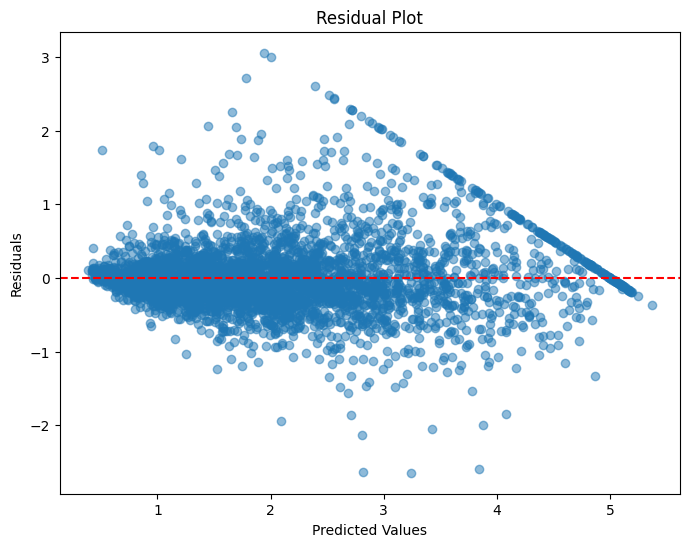

In [5]:
from src.visualization import (
    plot_residuals
)

plot_residuals(
    y_test,
    pred_xgb
)

## residual distribution

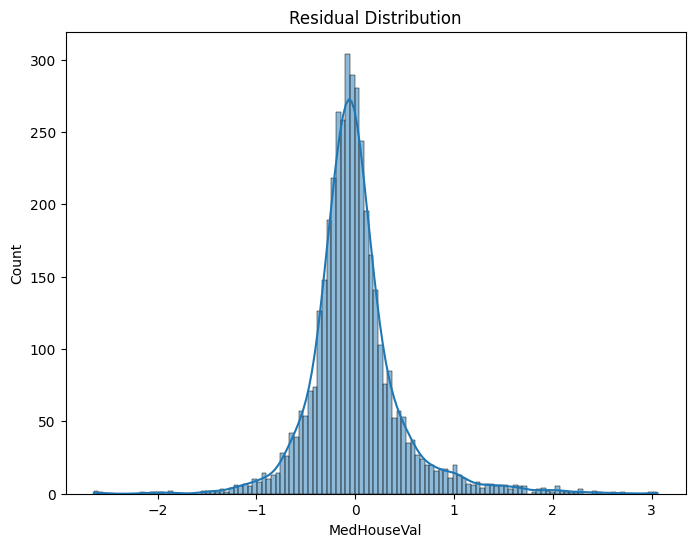

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - pred_xgb

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

### Residual Analysis Insight

The residual plot shows that prediction errors are generally centered around zero, indicating that the model does not exhibit strong systematic bias.

Most residuals are randomly distributed across the prediction range, suggesting that the XGBoost model captures the main structure of the data effectively.

The residual distribution is approximately bell-shaped and centered near zero, which is a desirable property for regression models. Larger errors appear mainly for expensive houses, likely due to the ceiling effect in the California Housing dataset where target values are capped at 5.0.

Overall, the residual analysis confirms that the model achieves strong predictive performance while maintaining relatively balanced prediction errors.
